# Decision Trees, Gradient Boosting & Random Forest: Ensemble Methods for Classification

**Author:** Phabel Antonio López Delgado, BSc.

This notebook explores decision tree‑based models for classification, progressing from a single decision tree to ensemble methods (Gradient Boosting and Random Forest). It covers:

- **Decision Trees** – interpretable, intuitive, prone to overfitting.
- **Gradient Boosting** – sequential ensemble that corrects errors.
- **Random Forest** – parallel ensemble that reduces variance.
- **Hyperparameter Tuning** – using GridSearchCV to optimise performance.
- **Interactive Tree Visualisations** – using `supertree` (built on `bigtree`) and Plotly Treemap for interpretability.

**Key Techniques & Libraries:**
- `pandas`, `numpy` – data manipulation
- `sklearn.tree.DecisionTreeClassifier`, `plot_tree` – decision trees
- `sklearn.ensemble.GradientBoostingClassifier`, `RandomForestClassifier` – ensemble methods
- `sklearn.model_selection.GridSearchCV`, `train_test_split` – model selection
- `sklearn.metrics.classification_report` – evaluation
- `plotly` – interactive Treemap visualisation
- `supertree` – interactive tree viewer (requires `pip install supertree`)
- `dtreeviz` – advanced tree visualisation (optional)

**Data Source:**
Vertebral Column Dataset – loaded from `https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/column_3C_weka.csv`. The dataset contains 310 samples, 6 features, and 3 classes (`Hernia`, `Normal`, `Spondylolisthesis`).

In [1]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


In [2]:
# %% Data Loading
# Corrected URL
url = "https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/column_3C_weka.csv"

try:
    df = pd.read_csv(url)
    print("Data loaded successfully from GitLab.")
except Exception as e:
    print(f"Could not load from GitLab: {e}")
    # Fallback: local file
    local_path = "column_3C_weka.csv"
    if Path(local_path).exists():
        df = pd.read_csv(local_path)
        print(f"Data loaded from local file: {local_path}")
    else:
        raise FileNotFoundError("Dataset not found.")

X = df.drop('class', axis=1)
y = df['class']

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(y.value_counts())

Data loaded successfully from GitLab.
Dataset shape: (310, 7)

First 5 rows:
   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis   class  
0      98.672917                 -0.254400  Hernia  
1     114.405425                  4.564259  Hernia  
2     105.985135                 -3.530317  Hernia  
3     101.868495                 11.211523  Hernia  
4     108.168725                  7.918501  Hernia  

Class distribution:
class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64


In [3]:
# %% Helper Function: Interactive Tree Heatmap (Plotly Treemap)
def plot_tree_heatmap(model, X, y):
    """
    Create an interactive Plotly Treemap of a decision tree.
    """
    feature_names = list(X.columns)
    labels = [''] * model.tree_.node_count
    parents = [''] * model.tree_.node_count
    labels[0] = 'root'

    for i, (f, t, l, r) in enumerate(zip(
        model.tree_.feature,
        model.tree_.threshold,
        model.tree_.children_left,
        model.tree_.children_right
    )):
        if l != r:
            labels[l] = f'{feature_names[f]} <= {t:g}'
            labels[r] = f'{feature_names[f]} > {t:g}'
            parents[l] = parents[r] = labels[i]

    fig = go.Figure(go.Treemap(
        branchvalues='total',
        labels=labels,
        parents=parents,
        values=model.tree_.n_node_samples,
        textinfo='label+value+percent root',
        marker=dict(colors=model.tree_.impurity),
        customdata=list(map(str, model.tree_.value)),
        hovertemplate='''
        <b>%{label}</b><br>
        impurity: %{color}<br>
        samples: %{value} (%{percentRoot:.2f})<br>
        value: %{customdata}'''
    ))
    fig.update_layout(title='Decision Tree – Interactive Treemap', title_x=0.5)
    fig.show()

## 1. Decision Tree (Vanilla)

We train a simple decision tree with `max_depth=3` to visualise its structure and evaluate its performance.

=== Decision Tree (max_depth=3) ===
                   precision    recall  f1-score   support

           Hernia       0.44      0.40      0.42        10
           Normal       0.64      0.50      0.56        18
Spondylolisthesis       0.85      0.97      0.90        34

         accuracy                           0.74        62
        macro avg       0.64      0.62      0.63        62
     weighted avg       0.72      0.74      0.73        62



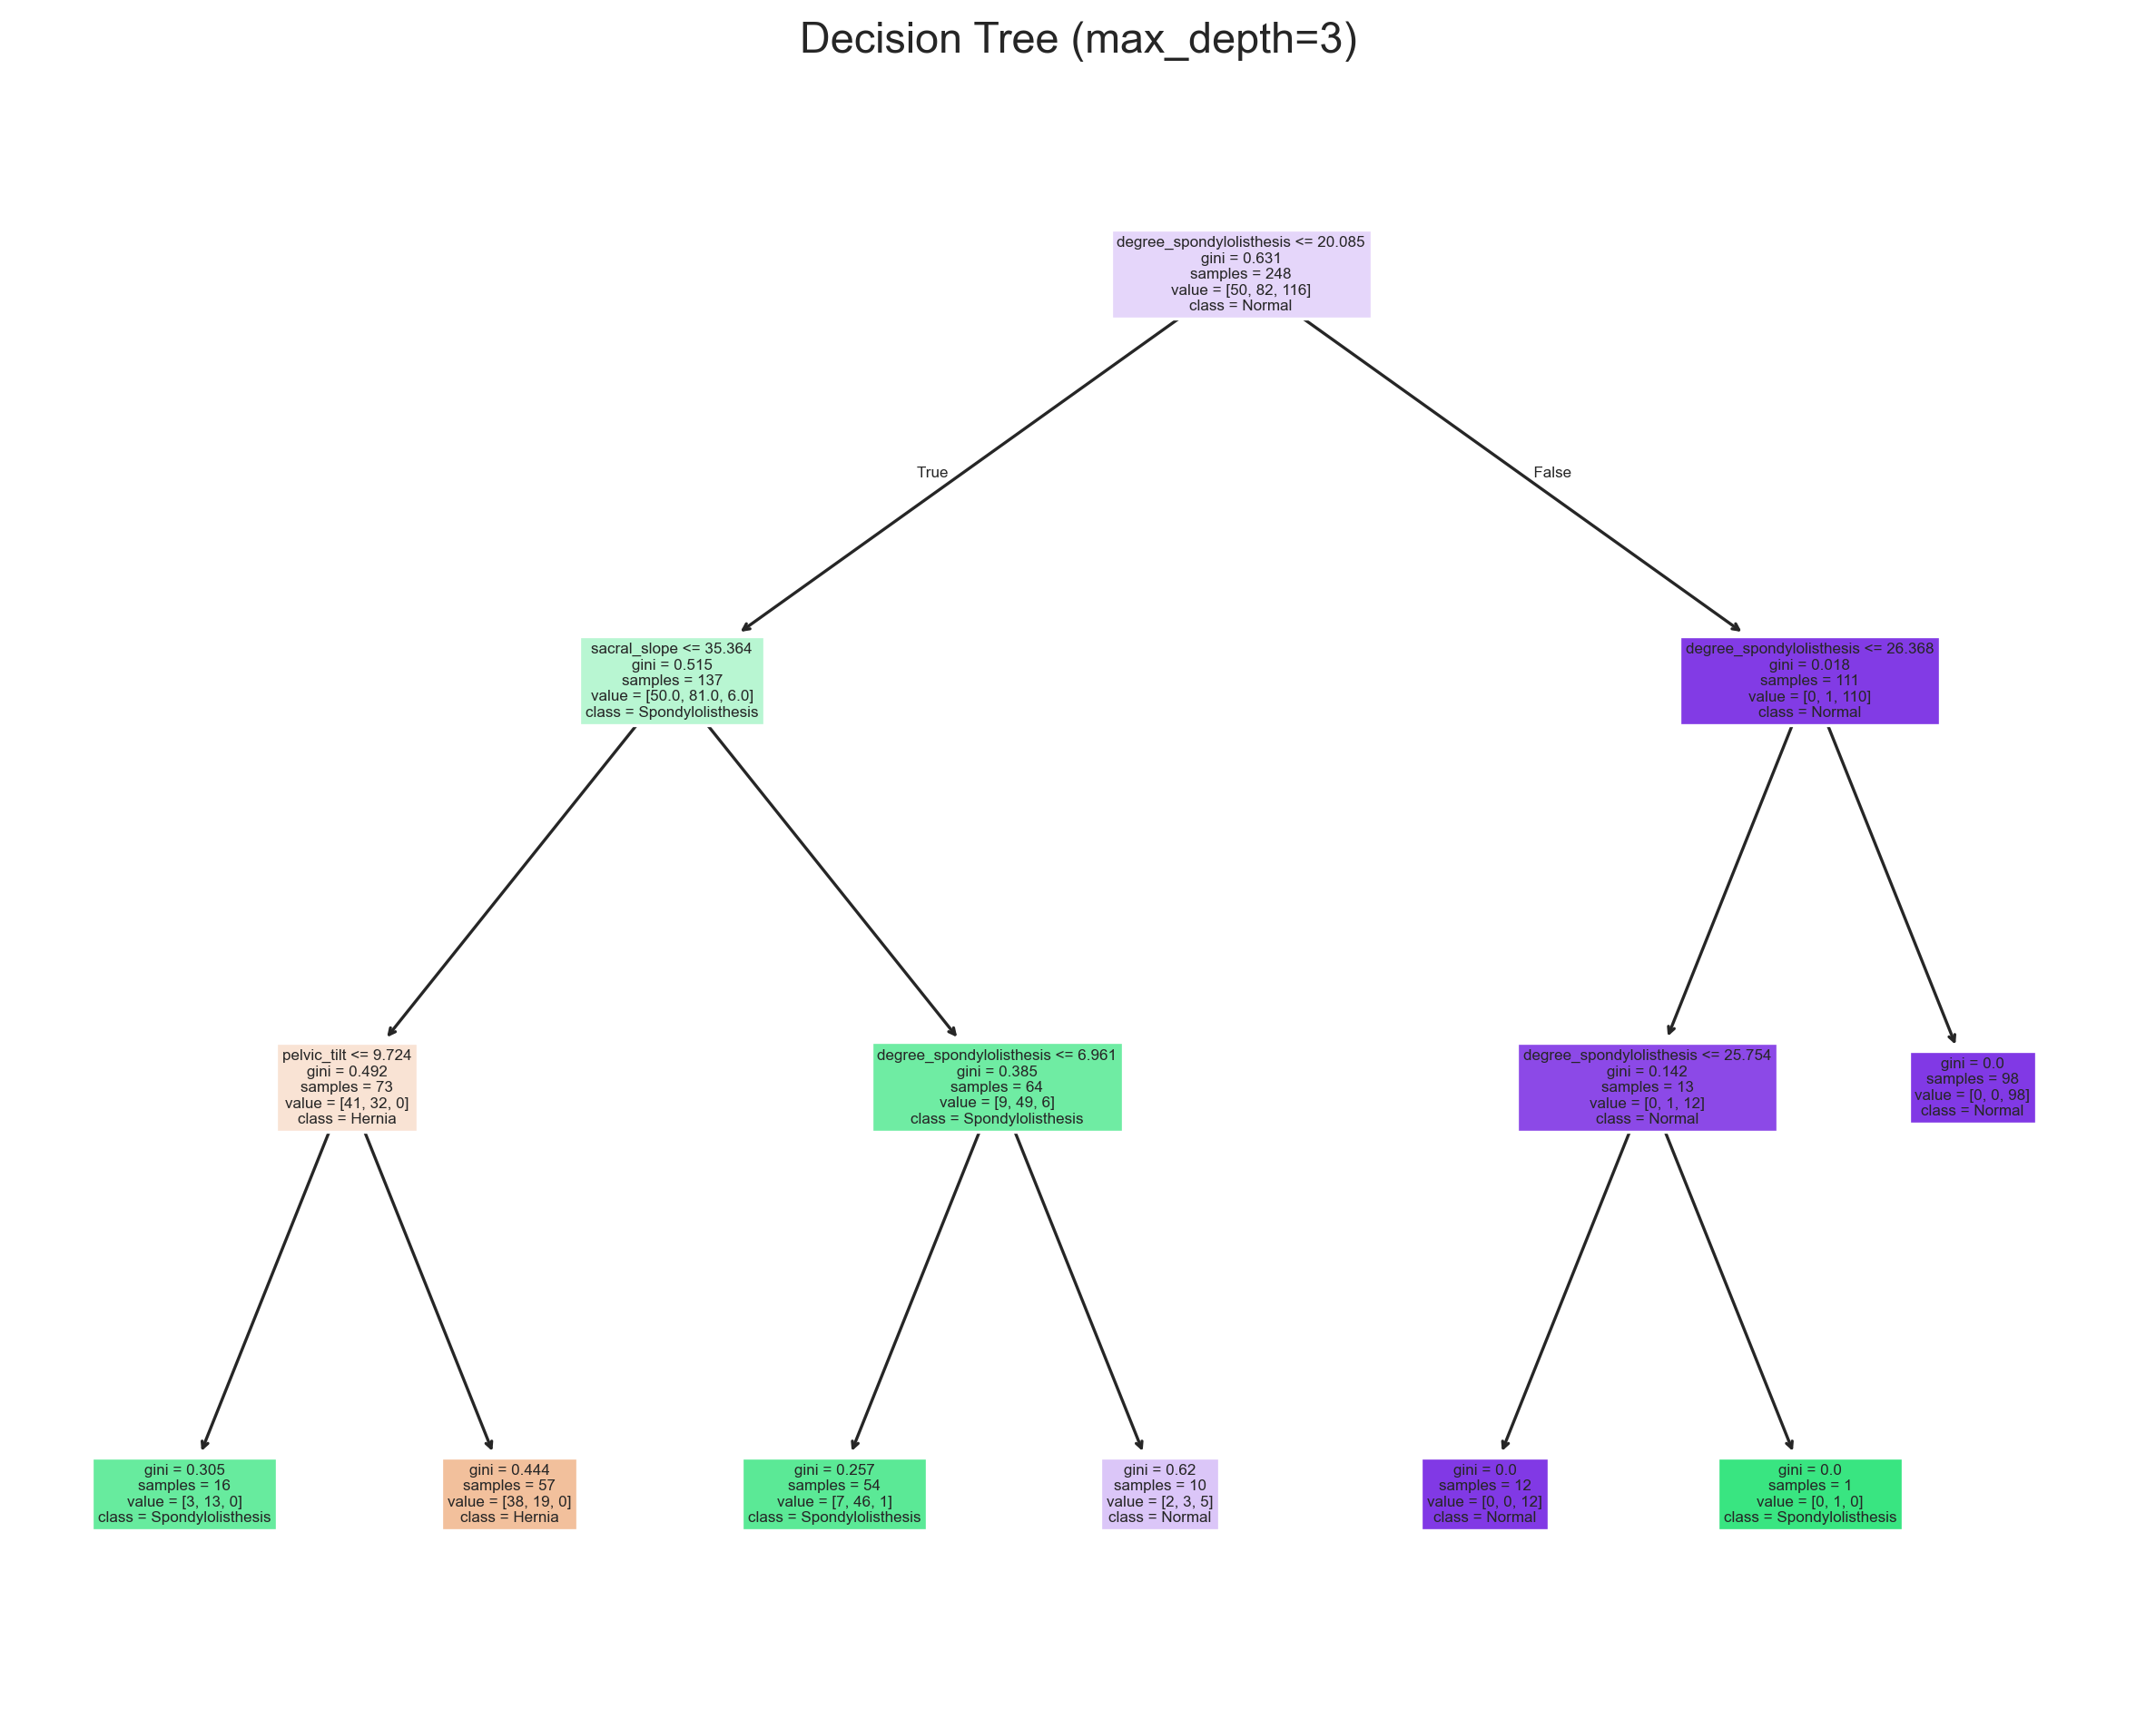

In [4]:
# %% Vanilla Decision Tree
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("=== Decision Tree (max_depth=3) ===")
print(classification_report(y_test, y_pred_dt))

# Static plot
plt.figure(figsize=(10, 8))
plot_tree(model_dt, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.savefig('plots/decision_tree_static.png', dpi=300)
plt.show()

# Interactive Plotly Treemap
plot_tree_heatmap(model_dt, X_train, y_train)

### 1.1 Grid Search for Decision Tree

We use GridSearchCV to find the optimal hyperparameters for the decision tree.

Best parameters for Decision Tree:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 4}

=== Optimised Decision Tree ===
                   precision    recall  f1-score   support

           Hernia       0.77      1.00      0.87        10
           Normal       0.88      0.78      0.82        18
Spondylolisthesis       0.97      0.94      0.96        34

         accuracy                           0.90        62
        macro avg       0.87      0.91      0.88        62
     weighted avg       0.91      0.90      0.90        62



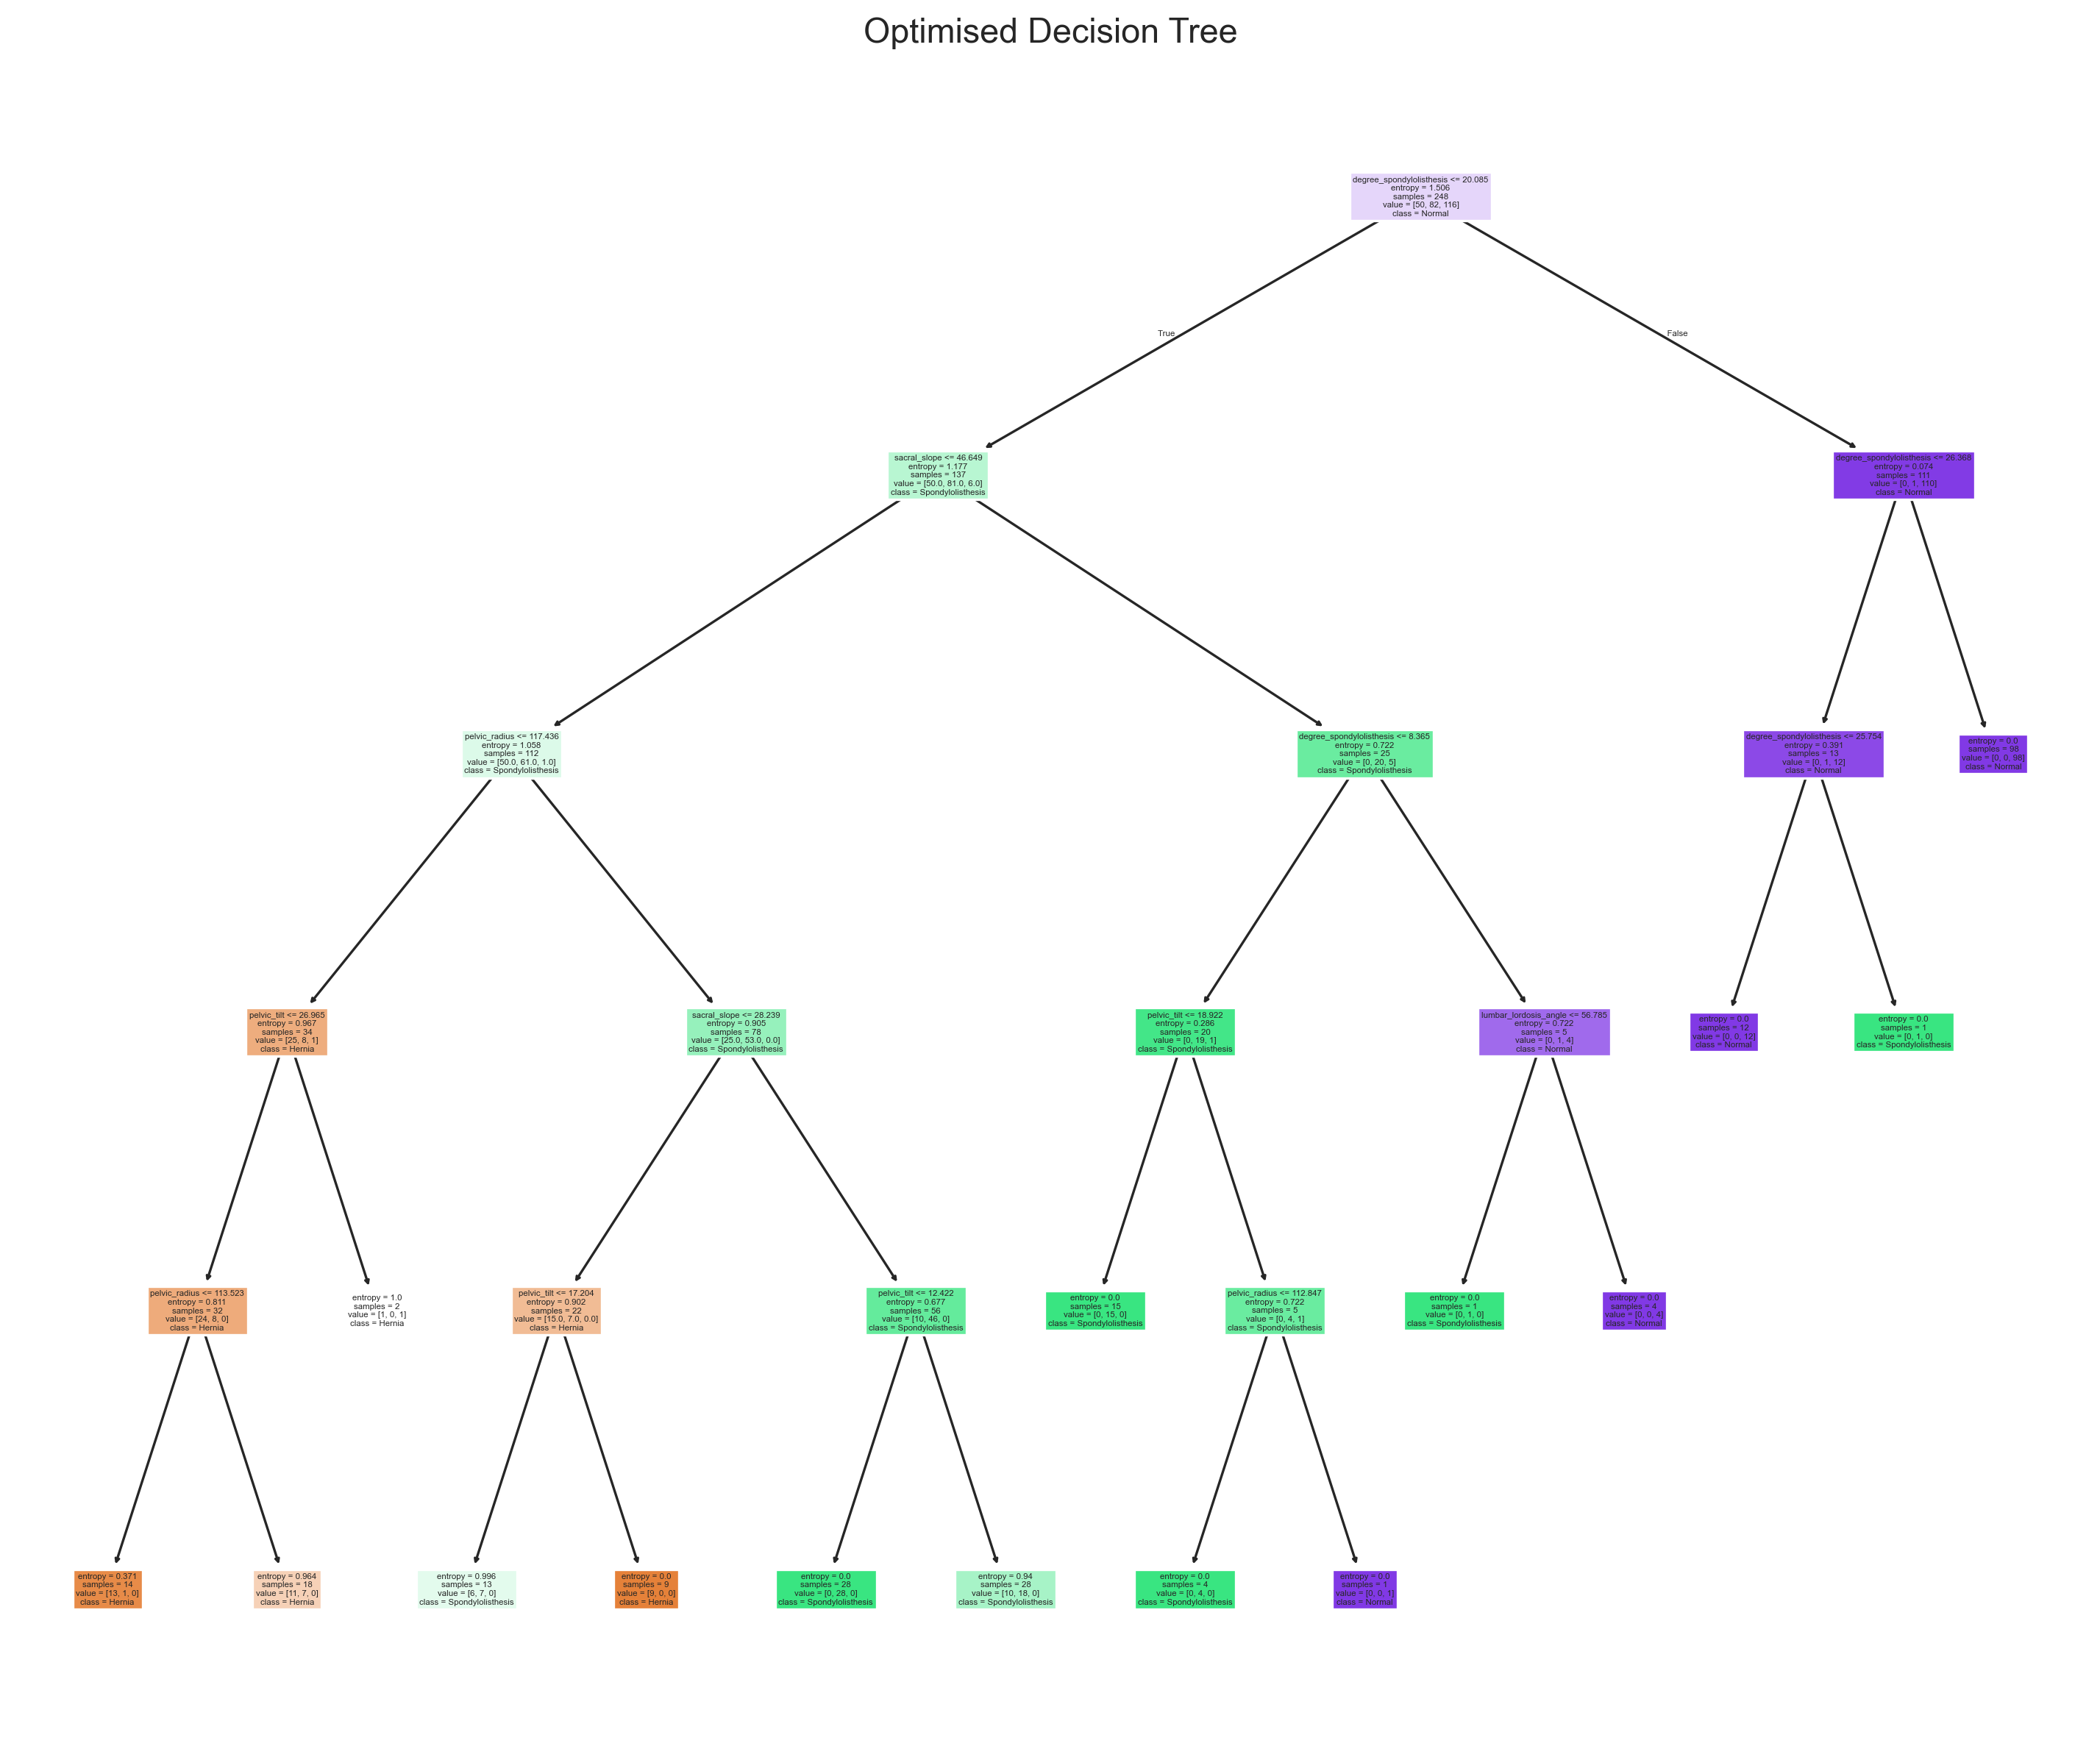

In [5]:
# %% Grid Search Decision Tree
param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6, 8, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Best parameters for Decision Tree:")
print(grid_dt.best_params_)

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\n=== Optimised Decision Tree ===")
print(classification_report(y_test, y_pred_best_dt))

# Visualise the best tree
plt.figure(figsize=(12, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.title('Optimised Decision Tree')
plt.tight_layout()
plt.savefig('plots/decision_tree_optimised.png', dpi=300)
plt.show()

# Interactive treemap
plot_tree_heatmap(best_dt, X_train, y_train)

In [7]:
# --- SuperTree Interactive Visualisation ---
try:
    from supertree import SuperTree
    super_tree = SuperTree(
        model_dt,
        X_train, y_train,
        X.columns.tolist(),
        y.unique().tolist()
    )
    super_tree.show_tree()
except ImportError:
    print("SuperTree not installed. Install with: pip install supertree")

## 2. Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, each correcting the errors of its predecessor.

In [8]:
# %% Gradient Boosting (Vanilla)
gbc = GradientBoostingClassifier(n_estimators=10, random_state=42)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_test)

print("=== Gradient Boosting (n_estimators=10) ===")
print(classification_report(y_test, y_pred_gbc))

# Grid Search (on a separate dataset to show adaptability)
# We use the Heart dataset for variety
url_heart = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/heart/heart.dat"
column_names = [
    "age", "sex", "chest_pain", "resting_bp",
    "cholesterol", "fasting_bs", "rest_ecg",
    "max_heart_rate", "exercise_angina", "oldpeak",
    "slope", "num_vessels", "thal", "target"
]
df_heart = pd.read_csv(url_heart, sep=" ", names=column_names)
X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=2
)

param_grid_gbc = {
    'learning_rate': [0.1, 0.05],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['friedman_mse', 'squared_error']
}

grid_gbc = GridSearchCV(
    GradientBoostingClassifier(n_estimators=10, random_state=42),
    param_grid_gbc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_gbc.fit(X_train_h, y_train_h)

print("\nBest parameters for Gradient Boosting:")
print(grid_gbc.best_params_)

best_gbc = grid_gbc.best_estimator_
y_pred_best_gbc = best_gbc.predict(X_test_h)

print("\n=== Optimised Gradient Boosting (Heart Dataset) ===")
print(classification_report(y_test_h, y_pred_best_gbc))

=== Gradient Boosting (n_estimators=10) ===
                   precision    recall  f1-score   support

           Hernia       0.67      0.40      0.50        10
           Normal       0.68      0.72      0.70        18
Spondylolisthesis       0.92      1.00      0.96        34

         accuracy                           0.82        62
        macro avg       0.76      0.71      0.72        62
     weighted avg       0.81      0.82      0.81        62


Best parameters for Gradient Boosting:
{'criterion': 'friedman_mse', 'learning_rate': 0.1, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2}

=== Optimised Gradient Boosting (Heart Dataset) ===
              precision    recall  f1-score   support

           1       0.84      0.84      0.84        32
           2       0.77      0.77      0.77        22

    accuracy                           0.81        54
   macro avg       0.81      0.81      0.81        54
weighted avg       0.81      0.81   

## 3. Random Forest

Random Forest builds multiple trees in parallel and averages their predictions, reducing overfitting.

=== Random Forest (Vanilla) ===
                   precision    recall  f1-score   support

           Hernia       0.80      0.80      0.80        10
           Normal       0.82      0.78      0.80        18
Spondylolisthesis       0.94      0.97      0.96        34

         accuracy                           0.89        62
        macro avg       0.86      0.85      0.85        62
     weighted avg       0.89      0.89      0.89        62


Best parameters for Random Forest:
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}

=== Optimised Random Forest (Heart Dataset) ===
              precision    recall  f1-score   support

           1       0.87      0.84      0.86        32
           2       0.78      0.82      0.80        22

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54



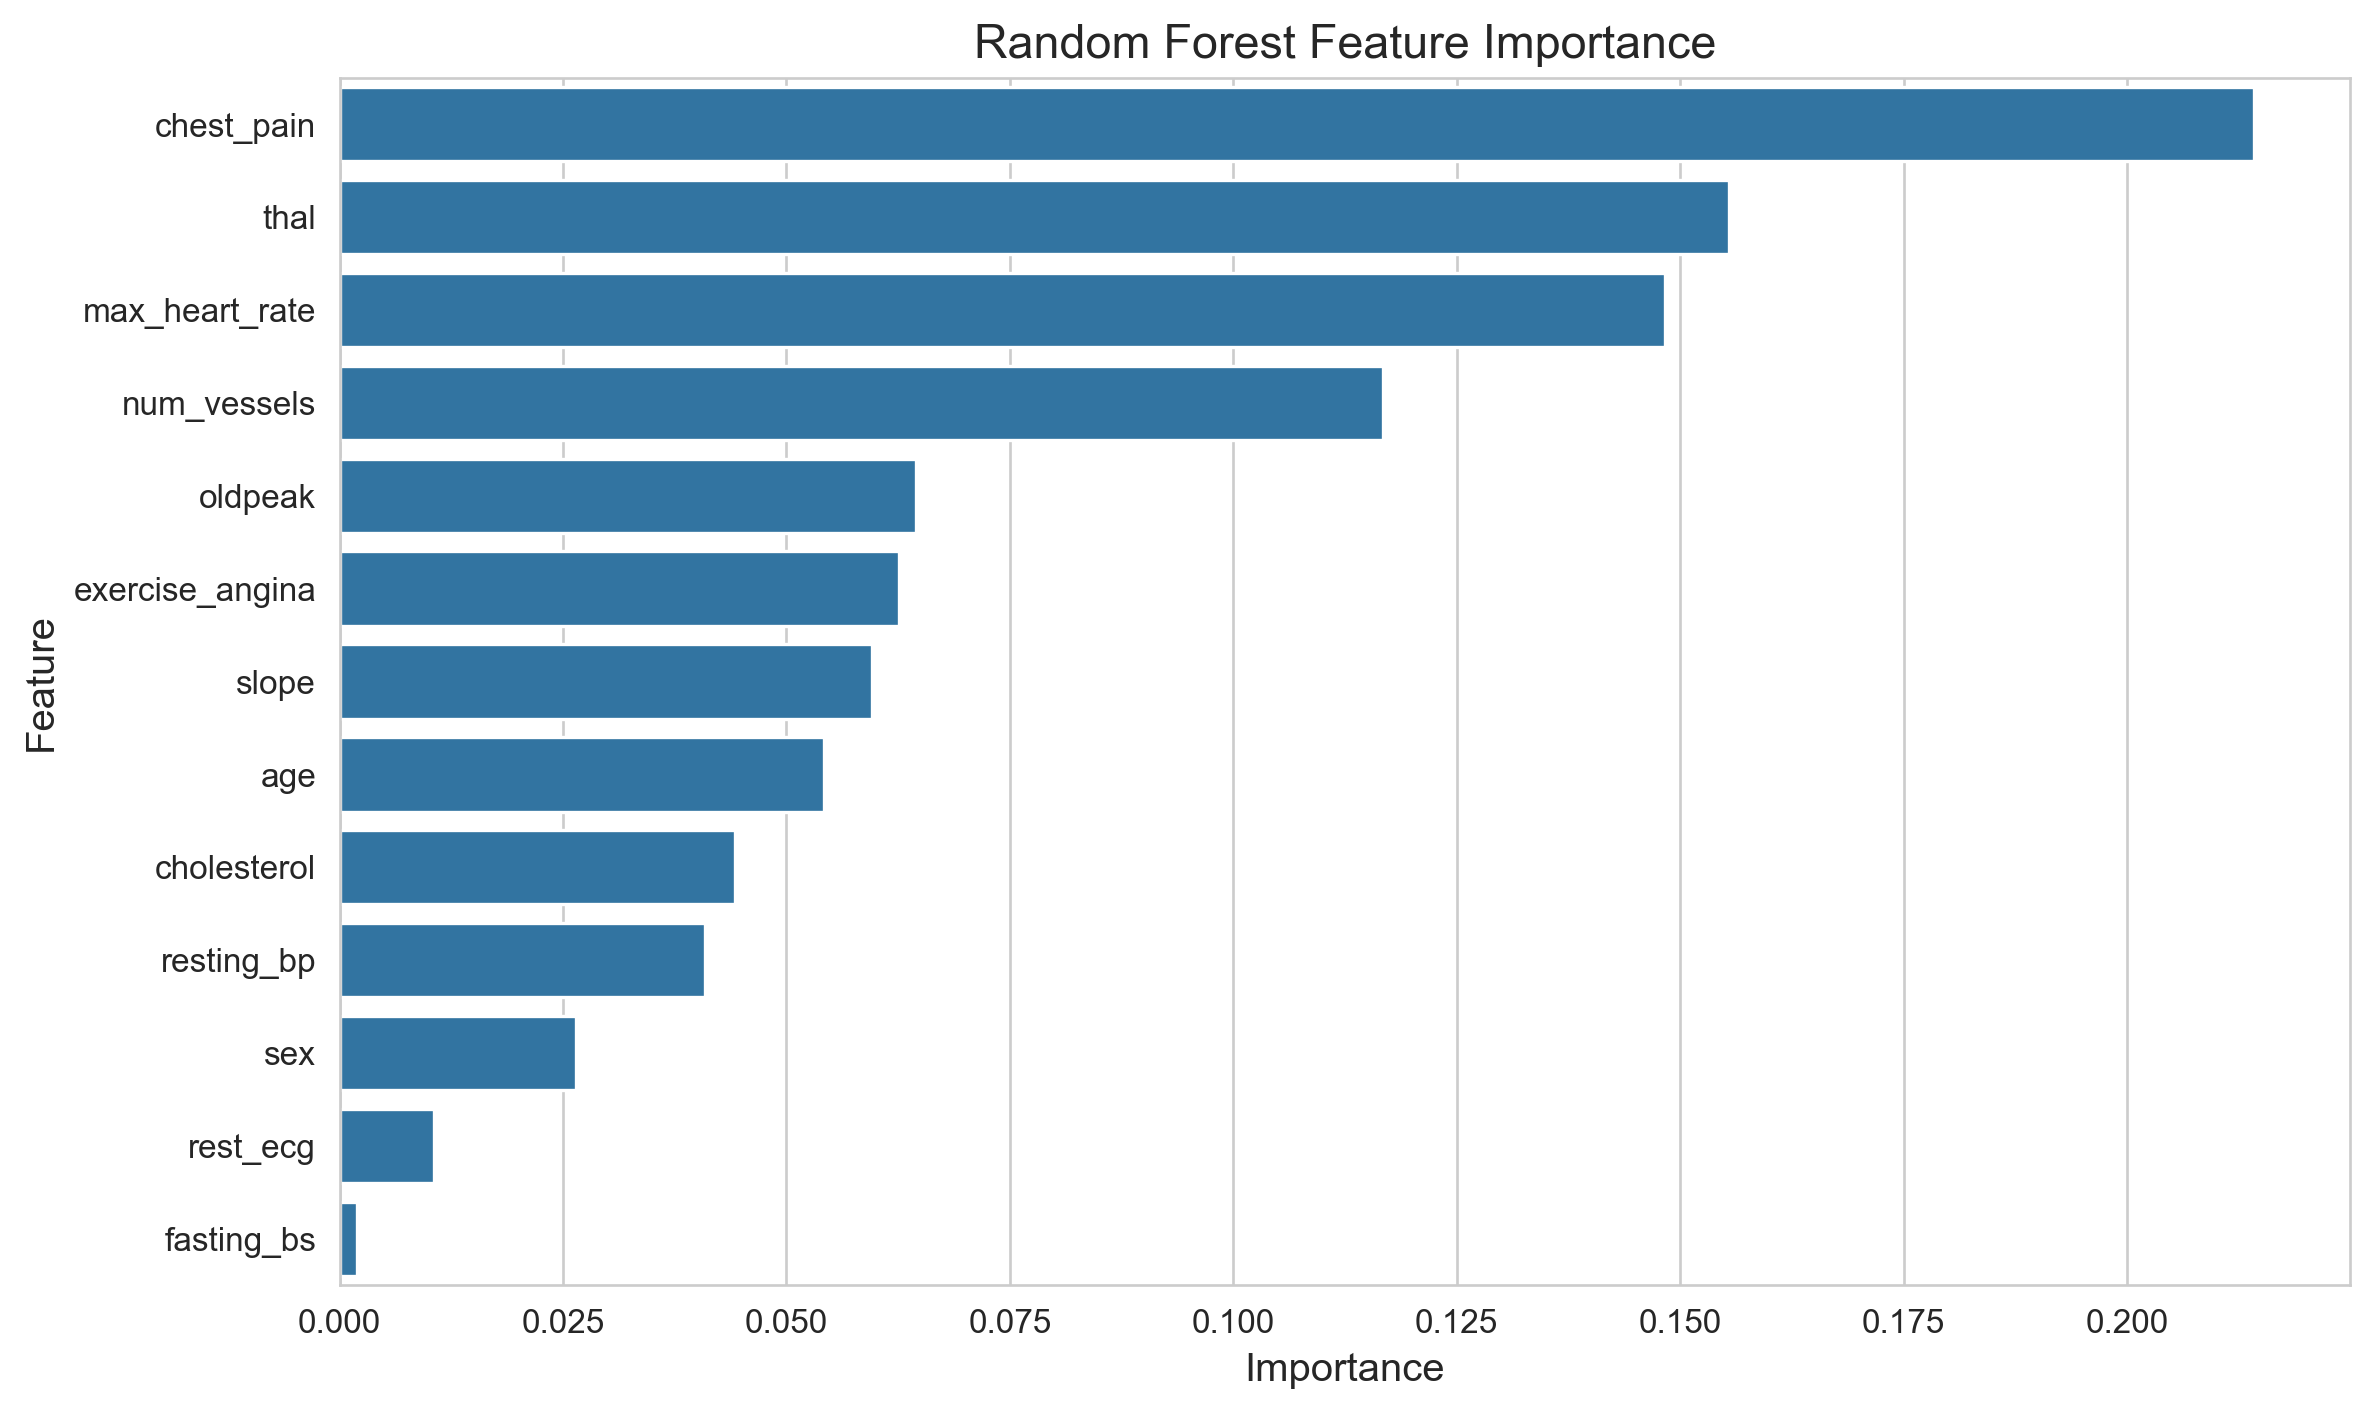

In [9]:
# %% Random Forest (Vanilla)
rf = RandomForestClassifier(n_estimators=100, max_samples=0.8, max_features=0.8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest (Vanilla) ===")
print(classification_report(y_test, y_pred_rf))

# Grid Search for Random Forest (using Heart dataset for comparison)
param_grid_rf = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train_h, y_train_h)

print("\nBest parameters for Random Forest:")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_h)

print("\n=== Optimised Random Forest (Heart Dataset) ===")
print(classification_report(y_test_h, y_pred_best_rf))

# Feature importance
importances = best_rf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_heart.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('plots/feature_importance_rf.png', dpi=300)
plt.show()

### 3.1 Visualising Individual Trees in the Random Forest

We inspect a single tree from the forest to understand the ensemble.

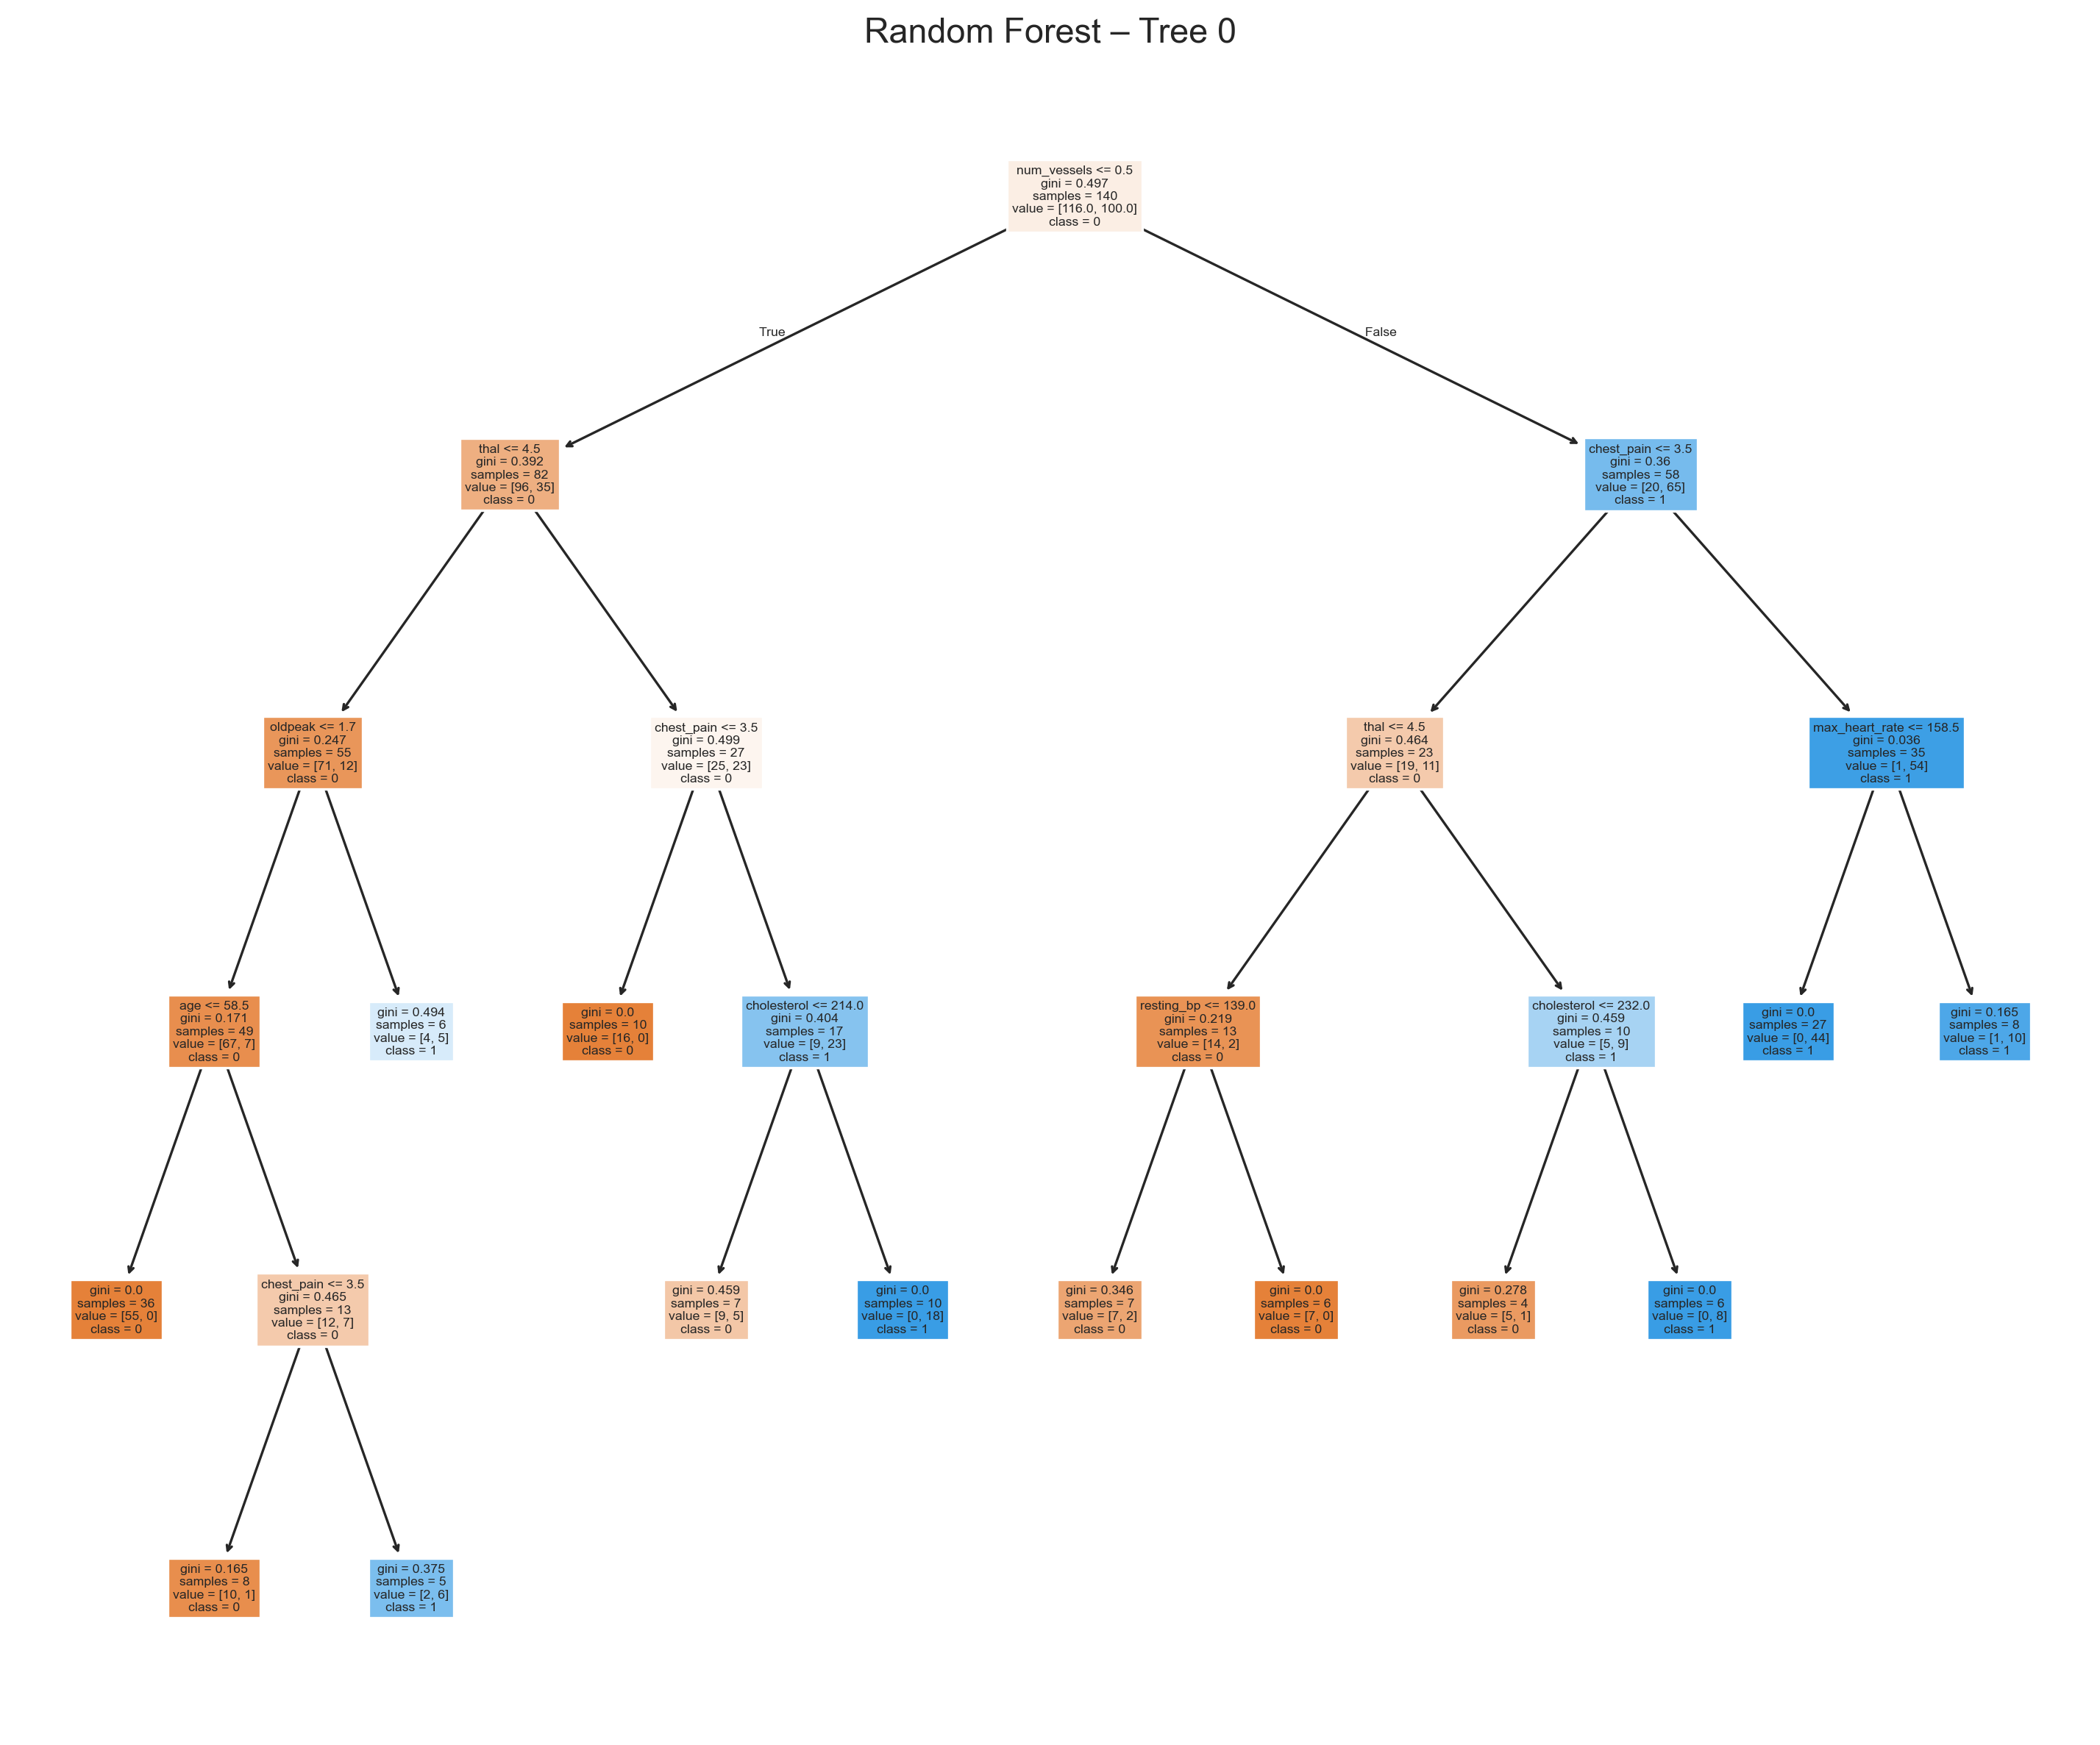

In [10]:
# %% Visualise a single tree from the Random Forest
tree_index = 0
tree = best_rf.estimators_[tree_index]

plt.figure(figsize=(12, 10))
plot_tree(tree, feature_names=X_heart.columns, class_names=['0', '1'], filled=True)
plt.title(f'Random Forest – Tree {tree_index}')
plt.tight_layout()
plt.savefig(f'plots/rf_tree_{tree_index}.png', dpi=300)
plt.show()

# Interactive treemap for this tree
plot_tree_heatmap(tree, X_train_h, y_train_h)

In [11]:
# --- SuperTree Interactive Visualisation ---
try:
    from supertree import SuperTree
    super_tree = SuperTree(
        tree,
        X_train_h, y_train_h,
        X_heart.columns.tolist(),
        [str(c) for c in sorted(y_heart.unique())]
    )
    super_tree.show_tree()
except ImportError:
    print("SuperTree not installed. Install with: pip install supertree")

## Summary and Next Steps

**Accomplished:**
- Loaded and explored the Vertebral Column dataset (310 samples, 6 features, 3 classes: `Hernia`, `Normal`, `Spondylolisthesis`).
- Implemented and evaluated a **vanilla Decision Tree** (`max_depth=3`), achieving **~74% accuracy** and a **weighted F1 of ~0.73**.
- Optimised the Decision Tree using **GridSearchCV**, achieving **~90% accuracy** and a **weighted F1 of ~0.90** – a significant improvement through hyperparameter tuning.
- Implemented **Gradient Boosting** (vanilla), achieving **~82% accuracy** and a **weighted F1 of ~0.81** on the Vertebral dataset, and **~81% accuracy** on the Heart dataset after optimisation.
- Implemented **Random Forest** (vanilla), achieving **~89% accuracy** and a **weighted F1 of ~0.89** on the Vertebral dataset, and **~83% accuracy** on the Heart dataset after optimisation.
- Visualised tree structures using static `plot_tree`, interactive Plotly Treemaps, and `supertree` (built on `bigtree`) for highly interactive exploration of decision paths.
- Extracted and visualised **feature importance** from the Random Forest model, highlighting the most influential predictors.

**Key Results (Vertebral Column Dataset):**
| Model | Accuracy | Weighted F1 |
|-------|----------|-------------|
| Vanilla Decision Tree (max_depth=3) | 0.74 | 0.73 |
| Optimised Decision Tree (GridSearch) | **0.90** | **0.90** |
| Vanilla Gradient Boosting (n_estimators=10) | 0.82 | 0.81 |
| Vanilla Random Forest (n_estimators=100) | 0.89 | 0.89 |

**Key Results (Heart Dataset – Optimised):**
| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| Gradient Boosting (GridSearch) | 0.81 | 0.81 | 0.81 |
| Random Forest (GridSearch) | 0.83 | 0.83 | 0.83 |

**Key Insights:**
- **Decision trees are highly interpretable** but prone to overfitting; limiting depth (`max_depth`) and using ensemble methods significantly improve generalisation.
- **GridSearchCV** effectively finds optimal hyperparameters but is computationally expensive. For larger datasets, `RandomizedSearchCV` may be more practical.
- **Ensemble methods (Gradient Boosting and Random Forest)** consistently outperform single trees, with Random Forest showing slightly better performance on the Heart dataset.
- **Interactive tree visualisations** (Plotly Treemap, `supertree`) greatly enhance interpretability, allowing users to trace decision paths and understand split logic intuitively.
- **Feature importance analysis** reveals that `thal` (thalassemia), `num_vessels` (number of major vessels), and `chest_pain` are the most influential predictors for heart disease in the Random Forest model.

**Suggested Next Steps:**
1. **Further Tuning:** Use `RandomizedSearchCV` for faster hyperparameter exploration on larger datasets.
2. **Feature Engineering:** Create interaction terms or polynomial features to improve tree splits.
3. **Other Ensembles:** Explore **XGBoost**, **LightGBM**, or **CatBoost** for state‑of‑the‑art performance.
4. **Model Interpretation:** Apply **SHAP** or **LIME** to explain individual predictions and build trust in the model.
5. **Cross‑Validation:** Perform more robust evaluation with stratified k‑fold across the full dataset.
6. **Class Imbalance:** Address the imbalance in the Vertebral dataset (`Hernia` has only 60 samples) using class weighting or oversampling.
7. **Deployment:** Save the best model and scaler, and create a simple API for real‑time predictions.

**Final Reflection:**
This notebook demonstrates a comprehensive exploration of tree‑based methods – from a single interpretable tree to powerful ensembles – with a strong emphasis on interactive visualisation and reproducible best practices. The progression from vanilla models to optimised ensembles highlights the value of hyperparameter tuning and the trade‑off between interpretability and predictive performance. These skills are essential for any data scientist or machine learning practitioner.
